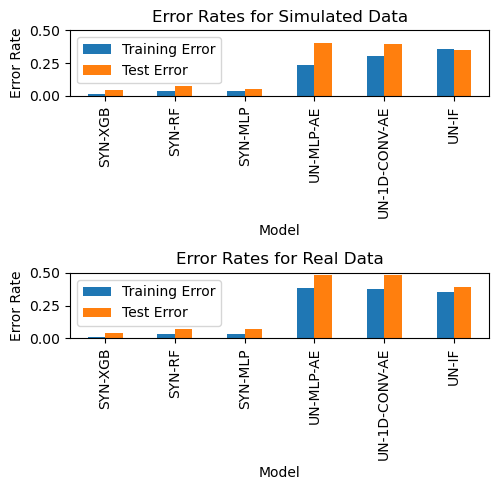

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data extracted from the table
data = {
    'Model': ['SYN-XGB', 'SYN-RF', 'SYN-MLP', 'UN-MLP-AE', 'UN-1D-CONV-AE', 'UN-IF',
              'SYN-XGB', 'SYN-RF', 'SYN-MLP', 'UN-MLP-AE', 'UN-1D-CONV-AE', 'UN-IF'],
    'DataSet': ['Sim_av']*6 + ['Real_av']*6,
    'AUC': [98.69, 96.76, 96.32, 76.18, 69.77, 64.28,
            98.74, 97.07, 97.04, 61.74, 62.61, 64.28],
    'ACC': [95.54, 92.75, 94.72, 59.35, 60.23, 64.92,
            95.83, 92.80, 93.26, 51.37, 51.70, 61.01]
}

# Convert percentages to proportions
for key in ['AUC', 'ACC']:
    data[key] = [value / 100.0 for value in data[key]]

# Convert to DataFrame
df = pd.DataFrame(data)

# Calculate the error rates as 1 - accuracy or AUC
df['Training Error'] = 1 - df['AUC']
df['Test Error'] = 1 - df['ACC']

# Separate the simulated and real data
simulated_df = df[df['DataSet'] == 'Sim_av']
real_df = df[df['DataSet'] == 'Real_av']

# Plotting the bar chart for Training and Test Error
fig, ax = plt.subplots(2, 1, figsize=(5, 5))

# Bar chart for Simulated Data
simulated_df.plot(x='Model', y=['Training Error', 'Test Error'], kind='bar', ax=ax[0])
ax[0].set_title('Error Rates for Simulated Data')
ax[0].set_ylabel('Error Rate')
ax[0].set_ylim(0, 0.5)

# Bar chart for Real Data
real_df.plot(x='Model', y=['Training Error', 'Test Error'], kind='bar', ax=ax[1])
ax[1].set_title('Error Rates for Real Data')
ax[1].set_ylabel('Error Rate')
ax[1].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()


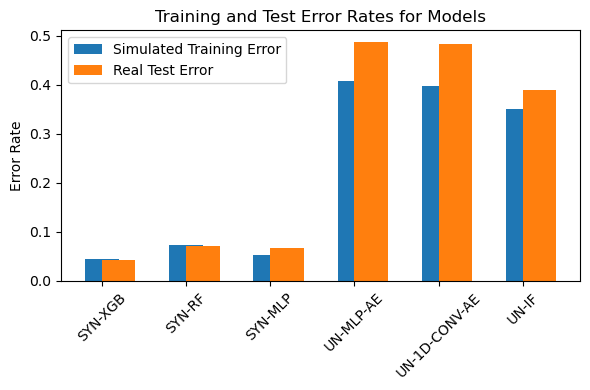

In [5]:
# Define the data from the table
data = {
    'Model': [
        'SYN-XGB', 'SYN-RF', 'SYN-MLP', 'UN-MLP-AE', 'UN-1D-CONV-AE', 'UN-IF',
        'SYN-XGB', 'SYN-RF', 'SYN-MLP', 'UN-MLP-AE', 'UN-1D-CONV-AE', 'UN-IF'
    ],
    'Dataset': [
        'Simulated', 'Simulated', 'Simulated', 'Simulated', 'Simulated', 'Simulated',
        'Real', 'Real', 'Real', 'Real', 'Real', 'Real'
    ],
    'AUC': [
        98.69, 96.76, 96.32, 76.18, 69.77, 64.28,
        98.74, 97.07, 97.04, 61.74, 62.61, 64.28
    ],
    'ACC': [
        95.54, 92.75, 94.72, 59.35, 60.23, 64.92,
        95.83, 92.80, 93.26, 51.37, 51.70, 61.01
    ]
}

# Convert the percentages to fractions
for key in ['AUC', 'ACC']:
    data[key] = [x / 100 for x in data[key]]

# Calculate training and test error as 1 - ACC
data['Training Error'] = [1 - x if dataset == 'Simulated' else None for x, dataset in zip(data['ACC'], data['Dataset'])]
data['Test Error'] = [None if dataset == 'Simulated' else 1 - x for x, dataset in zip(data['ACC'], data['Dataset'])]

# Create a DataFrame
df = pd.DataFrame(data)

# Plotting
fig, ax = plt.subplots(figsize=(6, 4))

# We have to split the data into two: one for simulated and one for real
simulated_data = df[df['Dataset'] == 'Simulated']
real_data = df[df['Dataset'] == 'Real']

# Since we want to plot the bars side by side, we need to have an offset for the x locations
x = range(len(simulated_data))
ax.bar(x, simulated_data['Training Error'], width=0.4, label='Simulated Training Error', align='center')
ax.bar(x, real_data['Test Error'], width=0.4, label='Real Test Error', align='edge')

# Set the x-tick labels to be the model names
ax.set_xticks(x)
ax.set_xticklabels(simulated_data['Model'], rotation=45)

# Set labels and title
ax.set_ylabel('Error Rate')
ax.set_title('Training and Test Error Rates for Models')
ax.legend()

# Show the plot
plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Train_test_error.png',bbox_inches='tight')
plt.show()
